In [1]:
# ✅ 1. Load JSON + Convert to DataFrame
import pandas as pd
import numpy as np
from datetime import datetime

# Load your JSON file
df = pd.read_json("tasks.json")

                                    _id                             projectId  \
0  0e87568e-fb7a-48db-996f-7f1c93e6a3e8  866fd030-e079-48d7-a2c4-5eb7f3f5ebf8   
1  c4c78995-1c5f-41ab-9aec-57cb246d3bc9  96911fe5-fe8f-4eb8-b3d0-948b71bf8643   
2  b2e93028-ee44-4da4-83c2-2f2d28fe8df7  89991470-2011-4e32-acc9-58b63c10f59f   
3  827916bd-4a46-4dd6-9d31-b4b2eedb30be  89991470-2011-4e32-acc9-58b63c10f59f   
4  cae95b91-7974-4c60-9ff3-4b9167981a86  89991470-2011-4e32-acc9-58b63c10f59f   

                        title  \
0                     testing   
1                       kmy6m   
2         Update dashboard UI   
3  Reduce startup bundle size   
4               Fix login bug   

                                         description priority      status  \
0               this is just for the testing purpose   medium  inprogress   
1                                           ky6okyop   medium        done   
2             Quick fix needed: Update dashboard UI.   medium        todo   
3  Ple

In [2]:
#✅ 2. Basic Cleaning
# Remove duplicates
df = df.drop_duplicates(subset=["_id"])

# Handle missing values
df["priority"] = df["priority"].fillna("low")
df["status"] = df["status"].fillna("todo")

# Comments (if not present, create)
if "comments_count" not in df.columns:
    df["comments_count"] = 0

In [3]:
# Convert to datetime
df["createdAt"] = pd.to_datetime(df["createdAt"], errors="coerce")
df["dueDate"] = pd.to_datetime(df["dueDate"], errors="coerce")
df["completedAt"] = pd.to_datetime(df["completedAt"], errors="coerce")

# Current time
now = pd.Timestamp.now()

In [28]:
# -----------------------------
# Ensure timezone is removed FIRST
# -----------------------------
df["createdAt"] = pd.to_datetime(df["createdAt"], errors="coerce").dt.tz_localize(None)
df["dueDate"] = pd.to_datetime(df["dueDate"], errors="coerce").dt.tz_localize(None)
df["completedAt"] = pd.to_datetime(df["completedAt"], errors="coerce").dt.tz_localize(None)

# Current time (tz-naive now matches)
now = pd.Timestamp.now()

# -----------------------------
# Feature Engineering
# -----------------------------

# Task age (in days)
df["task_age"] = (now - df["createdAt"]).dt.total_seconds() / (3600 * 24)

# Time left (can be negative if overdue)
df["time_left"] = (df["dueDate"] - now).dt.total_seconds() / (3600 * 24)

# Handle missing dueDate (VERY IMPORTANT)
# Fill missing dueDate using createdAt + default duration (e.g., 7 days)
df["dueDate"] = df["dueDate"].fillna(df["createdAt"] + pd.Timedelta(days=7))

# Recalculate time_left
df["time_left"] = (df["dueDate"] - now).dt.total_seconds() / (3600 * 24)

# Is overdue (CRITICAL FIX)
df["is_overdue"] = (df["time_left"] < 0).astype(int)

# Normalize status before using
df["status"] = df["status"].str.lower().str.strip()

# Is completed
df["is_completed"] = (df["status"] == "done").astype(int)

In [32]:
# Define delay (TARGET VARIABLE)

df["delayed"] = np.where(
    (df["completedAt"].notna()) & (df["completedAt"] > df["dueDate"]), 1,
    np.where(
        (df["completedAt"].isna()) & (df["time_left"] < 0), 1,
        0
    )
)
df[["time_left", "is_overdue", "delayed"]].describe()
df["delayed"].value_counts()

delayed
1    203
0    141
Name: count, dtype: int64

In [23]:
# Priority encoding
priority_map = {"low": 0, "medium": 1, "high": 2}
df["priority_encoded"] = df["priority"].map(priority_map)

# Status encoding (optional)
status_map = {"todo": 0, "inprogress": 1, "done": 2}
df["status_encoded"] = df["status"].map(status_map)

EDA

In [39]:
#🔹 Step 1: Basic overview (sanity check)
print(df.shape)
print(df.info())
print(df.describe())

(344, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   _id               344 non-null    object        
 1   projectId         344 non-null    object        
 2   title             344 non-null    object        
 3   description       344 non-null    object        
 4   priority          344 non-null    object        
 5   status            344 non-null    object        
 6   tags              344 non-null    object        
 7   dueDate           344 non-null    datetime64[ns]
 8   order             344 non-null    int64         
 9   userId            344 non-null    object        
 10  assignedTo        0 non-null      float64       
 11  assignees         344 non-null    object        
 12  boardId           344 non-null    object        
 13  createdAt         344 non-null    datetime64[ns]
 14  updatedAt       


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


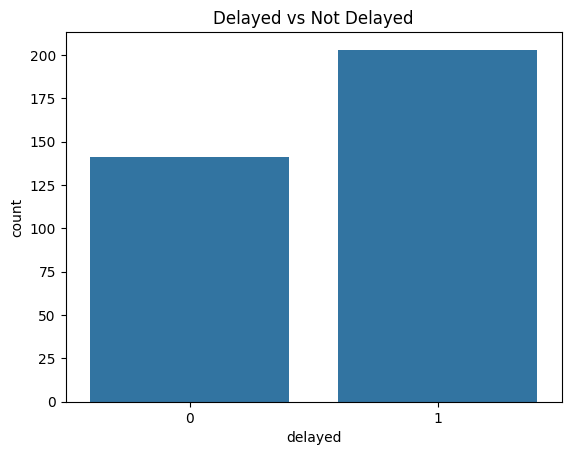

In [36]:
!pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="delayed", data=df)
plt.title("Delayed vs Not Delayed")
plt.show()

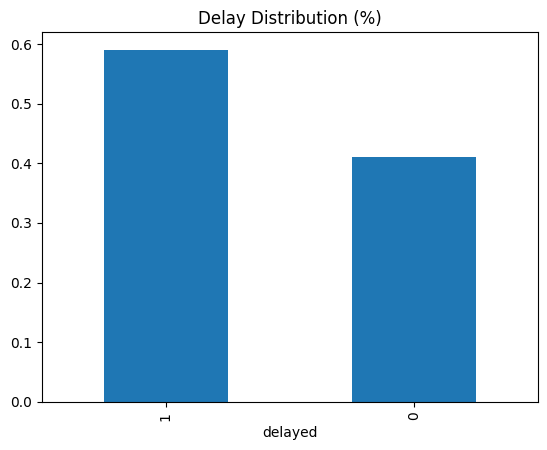

In [37]:
df["delayed"].value_counts(normalize=True).plot(kind="bar")
plt.title("Delay Distribution (%)")
plt.show()

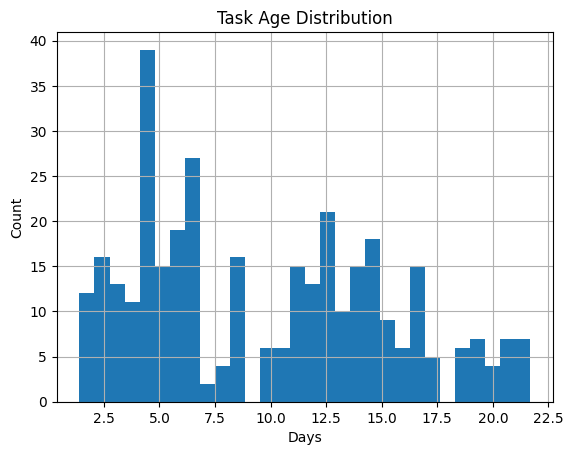

In [41]:


df["task_age"].hist(bins=30)
plt.title("Task Age Distribution")
plt.xlabel("Days")
plt.ylabel("Count")
plt.show()

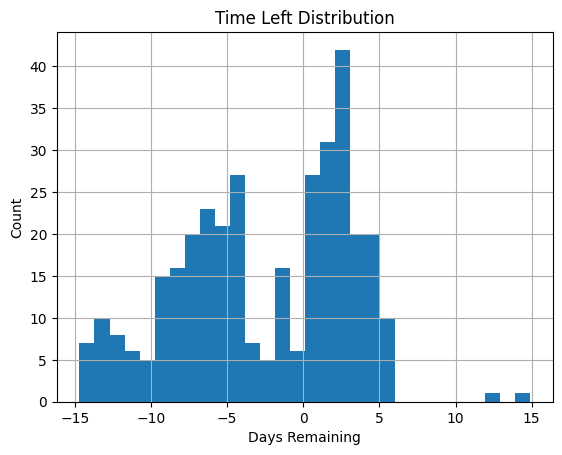

In [42]:
df["time_left"].hist(bins=30)
plt.title("Time Left Distribution")
plt.xlabel("Days Remaining")
plt.ylabel("Count")
plt.show()

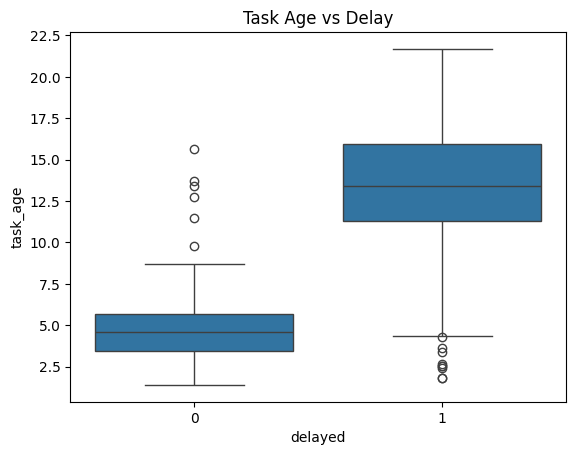

In [45]:


sns.boxplot(x="delayed", y="task_age", data=df)
plt.title("Task Age vs Delay")
plt.show()

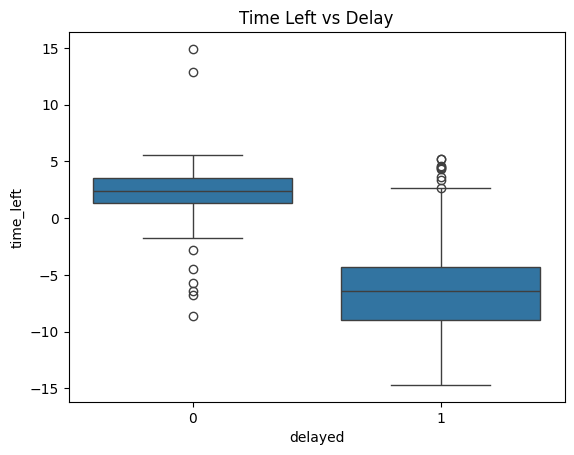

In [46]:
sns.boxplot(x="delayed", y="time_left", data=df)
plt.title("Time Left vs Delay")
plt.show()

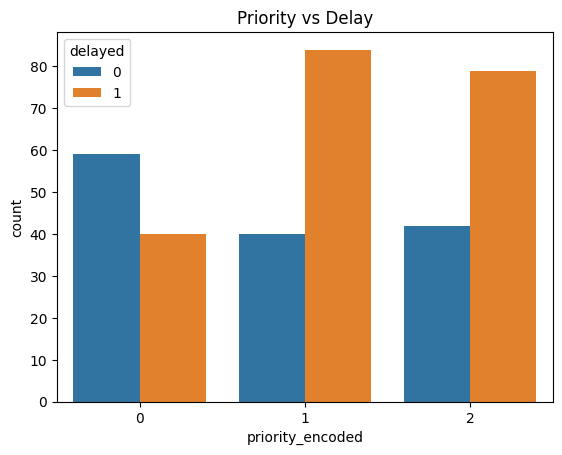

In [47]:
sns.countplot(x="priority_encoded", hue="delayed", data=df)
plt.title("Priority vs Delay")
plt.show()

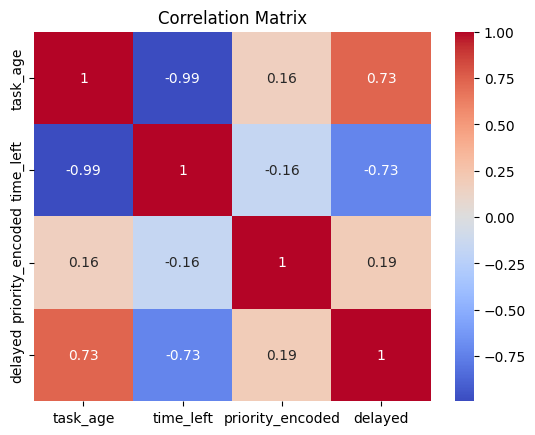

In [48]:


corr = df[["task_age", "time_left", "priority_encoded", "delayed"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


FEATURE SELECTION

In [50]:
features = ["time_left", "priority_encoded"]

X = df[features]
y = df["delayed"]

print(X.head())
print(y.value_counts())

   time_left  priority_encoded
0  12.911614                 1
1  14.911614                 1
2  -0.458628                 1
3  -7.692379                 2
4   4.136757                 0
delayed
1    203
0    141
Name: count, dtype: int64


🚀 Step: Train-Test Split

In [53]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df["delayed"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [54]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (275, 2)
Test shape: (69, 2)

Train distribution:
delayed
1    0.589091
0    0.410909
Name: proportion, dtype: float64

Test distribution:
delayed
1    0.594203
0    0.405797
Name: proportion, dtype: float64


🚀 Model Training (Baseline → Logistic Regression)

In [55]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [56]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("Confusion Matrix (LR):")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report (LR):")
print(classification_report(y_test, y_pred_lr))

Confusion Matrix (LR):
[[26  2]
 [ 6 35]]

Classification Report (LR):
              precision    recall  f1-score   support

           0       0.81      0.93      0.87        28
           1       0.95      0.85      0.90        41

    accuracy                           0.88        69
   macro avg       0.88      0.89      0.88        69
weighted avg       0.89      0.88      0.88        69



In [57]:
coef = dict(zip(features, lr.coef_[0]))
print("LR Coefficients:", coef)

LR Coefficients: {'time_left': -0.5843952134981885, 'priority_encoded': 0.2945507215605254}


In [58]:


results_lr = X_test.copy()
results_lr["actual"] = y_test
results_lr["predicted"] = y_pred_lr
results_lr["delay_risk_%"] = (y_prob_lr * 100).round(2)

print(results_lr.head())

     time_left  priority_encoded  actual  predicted  delay_risk_%
311   2.395862                 0       0          0          8.83
307   2.562529                 0       1          0          8.08
137  -5.687471                 1       1          1         93.61
107  -7.700722                 0       1          1         97.25
231   3.395862                 2       1          0          8.87


🚀 Next Step: Random Forest (Final Model)

In [59]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [60]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix (RF):")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report (RF):")
print(classification_report(y_test, y_pred_rf))

Confusion Matrix (RF):
[[25  3]
 [ 5 36]]

Classification Report (RF):
              precision    recall  f1-score   support

           0       0.83      0.89      0.86        28
           1       0.92      0.88      0.90        41

    accuracy                           0.88        69
   macro avg       0.88      0.89      0.88        69
weighted avg       0.89      0.88      0.88        69



In [61]:


importance = pd.Series(rf.feature_importances_, index=features)
print(importance.sort_values(ascending=False))

time_left           0.952313
priority_encoded    0.047687
dtype: float64


🚀 Next Step: Model Serialization

Now we save the model so it can be used in your app.

In [62]:
import joblib

joblib.dump(rf, "delay_model.pkl")

['delay_model.pkl']

In [63]:
joblib.dump(features, "features.pkl")

['features.pkl']